# Exploratory analysis — biomedical-rag-bench

The **exploratory** notebook (the scrappy first of two). Its job is to *de-risk* the polished
notebook: first establish the data is trustworthy, then sketch the headline figures. It imports
the one tested loader (`analysis/load.py`) — no load / dedup / reshape logic lives in cells.

Two steps, in this order on purpose:
- **Step 1 — the data: grain, dimensions, checks (*no charts*).** Can I *trust* this? Each
  dimension is shown with its realized value and linked to its canonical explanation in the READMEs.
- **Step 2 — metrics & insights (*charts*).** What does it *say*?

Run with the `eval` extra: `uv run --extra eval jupyter lab analysis/explore.ipynb`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[0]))  # repo root — this notebook lives in analysis/

import pandas as pd
from analysis.load import load, load_raw

df = load()
print(f"{len(df)} canonical rows · {df['retriever'].nunique()} retrievers · {df['type_id'].nunique()} types")

611 canonical rows · 6 retrievers · 10 types


## Step 1 — The data: grain, dimensions, checks (no charts)

No plots here. We state the **coordinate system** of the analysis — its *grain*, *dimensions*,
and *measures* — each shown with its realized value and linked to the canonical explanation, and
we *assert* the data matches what we claim. In pandas terms: **dimensions = groupby keys,
measures = agg targets, granularity = which keys you group on.** Step 2 then plots within it.

### Grain — one row = one trial

The atomic unit is **one `(question × retriever × generator × writer)` trial → a verdict**.
Everything downstream aggregates over it. The canonical dedup grain is `(retriever,
generator_model_family, writer_model_family, question_id)` — the writer family is in the key
because `graph_sparqlgen` runs a *second* LLM (the SPARQL writer) whose model is its own factor;
it is `NaN` for the no-writer retrievers, so those conditions collapse exactly as before.
→ [full result-row schema](../eval/README.md#result-row-schema)

In [2]:
key = ["retriever", "generator_model_family", "writer_model_family", "question_id"]
assert not df.duplicated(key).any(), "grain not unique — dedup bug in load.py"
print("grain unique on", key)
df[["question_id", "retriever", "generator_model", "passed"]].head(10)

grain unique on ['retriever', 'generator_model_family', 'writer_model_family', 'question_id']


,question_id,retriever,generator_model,passed
0,09_path_existence__path_between_compound_and_d...,graph_neighborhood,claude-haiku-4-5,0.0
1,08_negative_unanswerable__diseases_treated_by_...,graph_neighborhood,claude-haiku-4-5,1.0
2,07_set_difference__pathways_in_one_gene_exclud...,graph_neighborhood,claude-haiku-4-5,0.0
3,06_set_intersection__shared_pathways_of_two_ge...,graph_neighborhood,claude-haiku-4-5,0.0
4,05_aggregative__count_of_side_effects_caused_b...,graph_neighborhood,claude-haiku-4-5,0.0
5,03_2hop_traversal__genes_associated_with_compo...,graph_neighborhood,claude-haiku-4-5,0.0
6,02_1hop_factoid__genes_expressed_in_anatomy__00,graph_neighborhood,claude-haiku-4-5,1.0
7,01_0hop_attribute__chromosome_of_gene__00,graph_neighborhood,claude-haiku-4-5,1.0
8,04_3plus_hop_traversal__symptoms_of_pharmacolo...,graph_neighborhood,claude-haiku-4-5,0.0
9,04_3plus_hop_traversal__symptoms_of_pharmacolo...,closed_book,qwen2.5:3b-instruct,0.0


### Dimensions, by role

A factorial experiment has factors that are *varied* (under test), *held fixed* (for
comparability), and *confounded* (entangled — read with care). Naming the role up front is what
lets Step 2 say "we slice by type, we don't marginalize over it" and have it land.

**`retriever`** — *varied*; the condition under test (the swap point).
→ [Roster + per-retriever](../retrievers/README.md#roster)

In [3]:
df.groupby("retriever")["question_id"].nunique().rename("n_questions").sort_values(ascending=False)

retriever
closed_book                58
graph_neighborhood_1hop    58
graph_sparqlgen            58
graph_neighborhood_2hop    58
vector                     58
graph_neighborhood          9
Name: n_questions, dtype: int64

**`type_id`** — *varied*; the 10-type hop/structure taxonomy the H1 crossover is about.
→ [Question type taxonomy](../eval/README.md#question-type-taxonomy)

In [4]:
df.groupby("type_id")["question_id"].nunique().rename("n_questions")

type_id
01_0hop_attribute           3
02_1hop_factoid             5
03_2hop_traversal           7
04_3plus_hop_traversal      8
05_aggregative              8
06_set_intersection         5
07_set_difference           5
08_negative_unanswerable    7
09_path_existence           4
10_fuzzy_semantic           6
Name: n_questions, dtype: int64

**`generator`** — *held fixed within a run*, varied across runs. `generator_model` is the
*requested* id (may be a moving alias); `generator_model_resolved` is the *exact snapshot* the
provider ran. → [configured vs. resolved id](../eval/generate/README.md#the-model-under-test--configured-vs-resolved-id)

In [5]:
df[["generator_model", "generator_model_resolved", "generator_model_family"]].drop_duplicates().reset_index(drop=True)

,generator_model,generator_model_resolved,generator_model_family
0,claude-haiku-4-5,NaN,claude-haiku-4-5
1,qwen2.5:3b-instruct,qwen2.5:3b-instruct,qwen2.5:3b-instruct
2,qwen2.5:3b-instruct,NaN,qwen2.5:3b-instruct
3,claude-haiku-4-5,claude-haiku-4-5-20251001,claude-haiku-4-5


**`writer_model`** — *held fixed within a run, varied across runs* — but **only inside
`graph_sparqlgen`**, which runs a second LLM (the SPARQL writer, set by `SPARQLGEN_MODEL`) before
the generator. It is now a **canonical-grain dimension** (`writer_model_family`, date-normalized
exactly like the generator), so two writers are *separable conditions*, not a marginalized blur.
`NaN` for the four no-writer retrievers — which is correct, not missing. → [graph_sparqlgen](../retrievers/README.md#roster)

In [6]:
# graph_sparqlgen is the only arm with a writer; writer_model_family is NaN elsewhere (by design).
df[["retriever", "writer_model", "writer_model_family"]].drop_duplicates().reset_index(drop=True)

,retriever,writer_model,writer_model_family
0,graph_neighborhood,NaN,NaN
1,closed_book,NaN,NaN
2,vector,NaN,NaN
3,graph_neighborhood_1hop,NaN,NaN
4,graph_neighborhood_2hop,NaN,NaN
5,graph_sparqlgen,claude-haiku-4-5-20251001,claude-haiku-4-5
6,graph_sparqlgen,claude-sonnet-4-6,claude-sonnet-4-6


**`scoring`** — selects which judge/metric applies; **tied to `type_id`** (not independent).
→ [Strategy → judge map](../eval/judge/README.md#strategy--judge-map)

In [7]:
ct = pd.crosstab(df["type_id"], df["scoring"])
print("each type maps to exactly one scoring strategy:", bool((ct.gt(0).sum(axis=1) == 1).all()))
ct

each type maps to exactly one scoring strategy: True


scoring,binary,boolean,numerical,semantic,set_match,string_match
type_id,,,,,,
01_0hop_attribute,0,0,0,0,0,34
02_1hop_factoid,0,0,0,0,56,0
03_2hop_traversal,0,0,0,0,78,0
04_3plus_hop_traversal,0,0,0,0,89,0
05_aggregative,0,0,89,0,0,0
06_set_intersection,0,0,0,0,56,0
07_set_difference,0,0,0,0,56,0
08_negative_unanswerable,78,0,0,0,0,0
09_path_existence,0,45,0,0,0,0


### Confounds (named up front)

- **`type_id` ⟷ `scoring`** — each type has exactly one judge (crosstab above), so "by type" and
  "by scoring" are the *same* cut, not two independent dimensions.
- **hops ⟷ fan-caps** — raising graph hops without raising the fan caps *buries* the answer; a
  coupled knob, not a clean factor. → [FINDINGS caveat](FINDINGS.md)
- **writer-LLM inside `graph_sparqlgen`** — that arm runs an LLM *inside* retrieval; its token
  cost is a *mechanism* cost, logged separately and **never** summed with the generator's billed
  tokens. Its *model* is in the canonical grain (`writer_model_family`), so the writer is an
  **explicit dimension** now — haiku vs sonnet writer are distinct rows, no longer marginalized
  together. → [graph_sparqlgen](../retrievers/README.md#roster)

### Measures & granularities

**Measures:** `passed` → accuracy (binary) · `recall` / `precision` / `f1` (the richer picture) ·
`retrieval_context_input_tokens` + writer/judge LLM cost (*never summed*) · latency.
→ [Metrics](../eval/README.md#metrics) · [token-units rule](../retrievers/README.md#the-token-units-rule-read-before-doing-any-token-math)

**Granularities:** per-trial → per `(retriever × type)` **cell** (the heatmap) → per-retriever
**marginal** (*the misleading top-line — we slice, we don't marginalize*) → per-type marginal.

### Telemetry coverage — what's analyzable now vs. after the re-runs

The new retriever-telemetry columns are `NaN` for runs made before the harness persisted them, so
the writer-cost / cosine / top_k panels stay empty until the canonical re-runs land. This table is
the honest "what can I compute today" line.

In [8]:
cols = ["recall", "retrieval_context_input_tokens", "writer_input_tokens",
        "sparql_valid", "top_k", "hops", "cache_read_input_tokens"]
cov = pd.DataFrame({"non_null": [int(df[c].notna().sum()) if c in df else 0 for c in cols]},
                   index=cols)
cov["total"] = len(df)
cov["pct"] = (100 * cov.non_null / cov.total).round(0)
cov

,non_null,total,pct
recall,335,611,55.0
retrieval_context_input_tokens,611,611,100.0
writer_input_tokens,162,611,27.0
sparql_valid,162,611,27.0
top_k,109,611,18.0
hops,220,611,36.0
cache_read_input_tokens,342,611,56.0


### Reconciliation against the pinned baseline (the trust linchpin)

Does the loader reproduce the deterministic pass counts of the **canonical temp-0 baseline** (the
2026-06-09 sweep)? The expected counts are pinned to **specific frozen `run_id`s** — their `.jsonl`
is never overwritten, so this check never goes stale the way a *newest-run* view or a hand-typed
`FINDINGS.md` line does (every temp-0 re-run drifts those by ±1–3). The numbers live **here**, keyed
to the exact runs they came from; **re-baselining means deliberately swapping the `run_id`s + counts**,
not silently re-typing prose. A mismatch is therefore a real `load.py` regression — its dedup and
coverage logic is independently unit-tested in `tests/test_analysis_load.py`. We pin runs, not the
*newest* per condition, precisely because the newest closed_book / sparqlgen runs have since drifted
on temp-0 noise (→ the FINDINGS run log).

In [9]:
# Pinned to the 2026-06-09 temp-0 sweep by run_id (frozen jsonl), so it never drifts with later
# re-runs. Numbers live here keyed to their runs — NOT transcribed from FINDINGS prose. Use load_raw
# (pre-dedup): the newest run per condition has moved on, so the golden runs are no longer canonical.
GOLDEN = {  # run_id -> recorded deterministic passed/52
    "20260609T153917-closed_book-anthropic": 4,
    "20260609T154127-vector-anthropic": 9,
    "20260609T154316-graph_neighborhood_1hop-anthropic": 13,
    "20260609T154527-graph_neighborhood_2hop-anthropic": 13,
    "20260609T154741-graph_sparqlgen-anthropic": 16,
}
raw = load_raw()
got = (raw[raw["run_id"].isin(GOLDEN)]
       .assign(passed=lambda d: d["passed"] == True)
       .groupby("run_id")["passed"].sum())
rec = pd.DataFrame({"loader": got, "recorded": pd.Series(GOLDEN)})
rec["match"] = rec["loader"] == rec["recorded"]
rec

,loader,recorded,match
20260609T153917-closed_book-anthropic,4,4,True
20260609T154127-vector-anthropic,9,9,True
20260609T154316-graph_neighborhood_1hop-anthropic,13,13,True
20260609T154527-graph_neighborhood_2hop-anthropic,13,13,True
20260609T154741-graph_sparqlgen-anthropic,16,16,True


### Integrity checks

In [10]:
print("error rows:", int(df["error"].notna().sum()) if "error" in df else 0)
print("unjudged non-semantic rows:", int(((~df["judged"]) & (df["scoring"] != "semantic")).sum()))
print("max generators per run (should be 1):", int(df.groupby("run_id")["generator_model"].nunique().max()))

error rows: 1
unjudged non-semantic rows: 1
max generators per run (should be 1): 1


## Step 2 — Metrics & insights (charts)

The frame is trusted, so we plot *within* the coordinate system Step 1 defined. Cost/writer panels
are `NaN` until the canonical re-runs on the new telemetry schema (see coverage above) — they light
up automatically when those land, since the notebook just re-imports `load()`.

In [11]:
import matplotlib.pyplot as plt

# The canonical surface every Step-2 figure slices: the haiku generator and (for graph_sparqlgen)
# the haiku SPARQL writer. The qwen-generator and sonnet-writer runs are separate comparison studies
# (Figs 1a/1b below); pinning one surface here keeps the recall/precision/cost figures from averaging
# distinct conditions. The retriever×type accuracy heatmap that used to live here is now Fig 1a's
# haiku panel — same data, minus the legacy 9-question graph_neighborhood that the 1a reindex drops.
canon = df[(df["generator_model_family"] == "claude-haiku-4-5")
           & (df["writer_model_family"].isna() | (df["writer_model_family"] == "claude-haiku-4-5"))]

### Fig 1a — Generator facet (qwen2.5:3b vs haiku)

Two side-by-side panels, **same writer (haiku/none), one per generator** — the full retriever × type
heatmap under each. Panels are ordered **weak → strong generator (qwen2.5:3b → haiku)**, so reading
left→right is reading *improvement*. Writer pinned so `graph_sparqlgen`'s two writers aren't averaged
within a panel; rows/columns share a fixed order so the panels are directly comparable, and the legacy
9-question `graph_neighborhood` is dropped. **Caveat:** qwen ran the deterministic set on the same
`question_id`s — a blank cell means *no run there* (coverage), not zero accuracy.

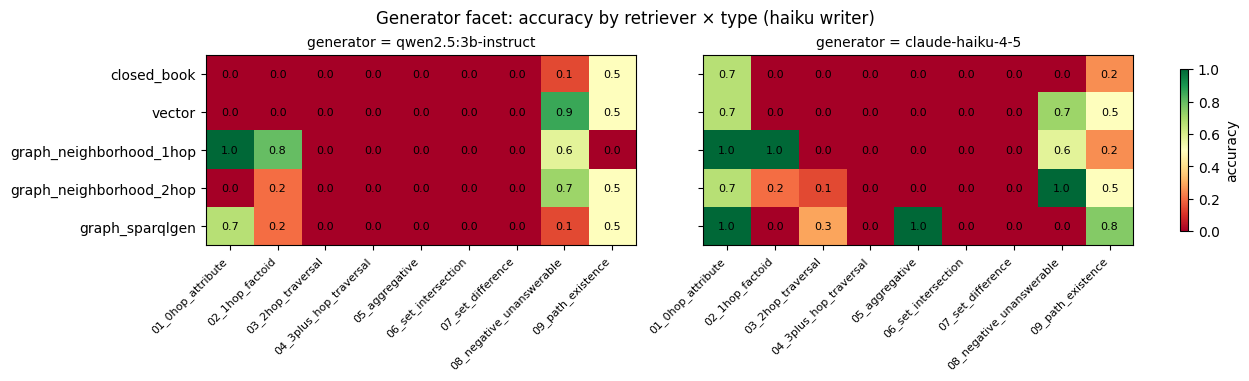

In [12]:
# Shared faceting helpers (used by Fig 1a and Fig 1b). _heatmap = imshow + per-cell text on a shared
# RdYlGn 0–1 scale so every panel is directly comparable; _facet lays panels SIDE BY SIDE with one
# shared colorbar and y-labels only on the leftmost panel.
def _heatmap(ax, piv, title):
    im = ax.imshow(piv.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8)
    ax.set_title(title, fontsize=10)
    return im

def _facet(panels, suptitle):
    fig, axes = plt.subplots(1, len(panels), figsize=(6.2 * len(panels), 3.7), squeeze=False, layout="constrained")
    im = None
    for k, (ax, (label, piv)) in enumerate(zip(axes[0], panels)):
        im = _heatmap(ax, piv, label)
        if k > 0:
            ax.set_yticklabels([])  # rows shared across panels; label once
    fig.colorbar(im, ax=axes.ravel().tolist(), label="accuracy", shrink=0.85)
    fig.suptitle(suptitle, fontsize=12)
    return fig

# Canonical surface for both facets: haiku generator, deterministic types, fixed row/col order.
RETR_ORDER = ["closed_book", "vector", "graph_neighborhood_1hop", "graph_neighborhood_2hop", "graph_sparqlgen"]
det = df[(df["generator_model_family"] == "claude-haiku-4-5") & (df["scoring"] != "semantic")]
TYPE_ORDER = sorted(det["type_id"].unique())

# Generator facet: one panel per generator (writer pinned to haiku/NaN so sparqlgen's two writers
# aren't averaged). The legacy 9-question graph_neighborhood is dropped by the reindex. Blank cell =
# no run there (coverage), not zero — qwen ran deterministic.
det_all = df[(df["scoring"] != "semantic")
             & (df["writer_model_family"].isna() | (df["writer_model_family"] == "claude-haiku-4-5"))]
# Panels ordered weak -> strong generator (qwen2.5:3b -> haiku) so reading left->right is reading
# improvement; explicit (not sorted()) so the narrative order survives a model rename. Absent models
# are skipped, not blanked.
GEN_ORDER = ["qwen2.5:3b-instruct", "claude-haiku-4-5"]
present = set(det_all["generator_model_family"].dropna().unique())
gens = [g for g in GEN_ORDER if g in present]
gpanels = [(f"generator = {g}",
            det_all[det_all["generator_model_family"] == g]
            .pivot_table(index="retriever", columns="type_id", values="passed", aggfunc="mean")
            .reindex(index=RETR_ORDER, columns=TYPE_ORDER))
           for g in gens]
_facet(gpanels, "Generator facet: accuracy by retriever × type (haiku writer)");

### Fig 1b — SPARQL writer comparison (does a stronger SPARQL writer help?)

Only `graph_sparqlgen` runs a SPARQL writer, so the other four retrievers are **identical across
writers by construction** — drawing them twice (as a side-by-side heatmap would) buries the one row
that can change under ~40 cells that can't. So we **drop the writer-independent backdrop** (it's
already in Fig 1a) and isolate `graph_sparqlgen`, generator fixed to haiku: a **dumbbell per type** —
haiku dot vs sonnet dot, connected. Coincident dots = no writer effect; a colored line = the writer
moved it (red = sonnet did *worse*). **Absolute level is kept on purpose:** a pair pinned at 1.0
(writer irrelevant because both succeed) and one at 0.0 (irrelevant because both fail) are opposite
stories a difference view would collapse to the same blank. Expectation from the session-18 finding:
a stronger writer does **not** help; once the query is valid, capability stops mattering — the
ceiling is query↔ground-truth *alignment*, not writer skill.

writer_model_family,claude-haiku-4-5,claude-sonnet-4-6
type_id,,
01_0hop_attribute,1.00,1.00
02_1hop_factoid,0.00,0.00
03_2hop_traversal,0.29,0.14
04_3plus_hop_traversal,0.00,0.00
05_aggregative,1.00,1.00
06_set_intersection,0.00,0.00
07_set_difference,0.00,0.00
08_negative_unanswerable,0.00,0.00
09_path_existence,0.75,0.25


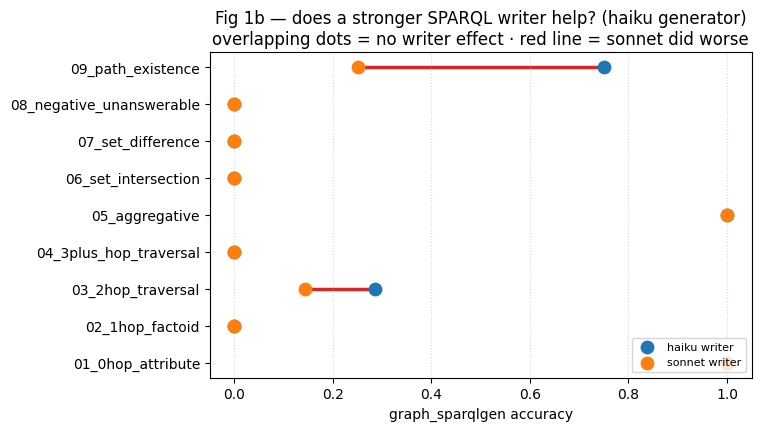

In [13]:
# SPARQL writer comparison, repainted as a dumbbell. Only graph_sparqlgen has a writer, so the four
# writer-independent retrievers are dropped (identical across writers by construction; they're in
# Fig 1a) and we isolate the one arm that can move. Per type: a haiku dot vs a sonnet dot, connected.
# Overlapping dots = no writer effect; a colored line = the writer moved it (red = sonnet did worse).
# Absolute level is kept on purpose — a flat pair at 1.0 (irrelevant: both succeed) and one at 0.0
# (irrelevant: both fail) are opposite stories a diff strip would erase. Reuses det/TYPE_ORDER from 1a.
gs = det[det["retriever"] == "graph_sparqlgen"]
wp = (gs.pivot_table(index="type_id", columns="writer_model_family", values="passed", aggfunc="mean")
        .reindex(TYPE_ORDER).dropna(how="all"))
H, S = "claude-haiku-4-5", "claude-sonnet-4-6"
y = list(range(len(wp)))

fig, ax = plt.subplots(figsize=(7.5, 4.2), layout="constrained")
for yi, th, ts in zip(y, wp[H], wp[S]):
    c = "0.75" if ts == th else ("tab:green" if ts > th else "tab:red")
    ax.plot([th, ts], [yi, yi], color=c, lw=2.5, zorder=1)
ax.scatter(wp[H], y, s=80, color="tab:blue",   label="haiku writer",  zorder=2)
ax.scatter(wp[S], y, s=80, color="tab:orange", label="sonnet writer", zorder=2)
ax.set_yticks(y); ax.set_yticklabels(wp.index)
ax.set_xlim(-0.05, 1.05); ax.set_xlabel("graph_sparqlgen accuracy")
ax.set_title("Fig 1b — does a stronger SPARQL writer help? (haiku generator)\n"
             "overlapping dots = no writer effect · red line = sonnet did worse")
ax.legend(loc="lower right", fontsize=8); ax.grid(axis="x", ls=":", alpha=0.5)
wp.round(2)

### Fig 2 — Recall vs. exact-set pass (the `graph_sparqlgen` finding)

For set-type questions (ground truth is a *set* of items, scored by `set_match`), two bars per
retriever:

- **`mean_recall`** — of the items that *should* be in the answer, what fraction did the retriever
  actually fetch? Ignores extras.
- **`exact_pass_rate`** — fraction of questions the binary judge passed. `set_match` passes **only on
  an exact set**: nothing missing *and* nothing extra.

**Recall here is diagnostic, not redemptive.** High recall does *not* rescue a failed trial — the
eval scores the exact set, and nothing reliably converts a high-recall/low-precision retrieval into a
pass. *Where* precision is decided differs by arm, but the generator never closes the gap either way:

- **`graph_sparqlgen`** — precision is owned by the **SPARQL writer's WHERE clause**. The query
  collapses the graph to its projection (`var=value` rows), so the discriminative signal is gone:
  extras from a relaxed constraint look identical to real answers and the generator, unable to tell
  them apart, just reports the result set. The generator *cannot* prune.
- **neighborhood** — precision is **shared**: the retriever's fan-out sets the superset, and the
  generator *could* prune it, because the context is labeled triples (`subj pred obj`) where the edge
  type that exposes an off-relation neighbor survives. But empirically it prunes badly
  (`graph_neighborhood_1hop`: ~8.5 extra rows, precision 0.26 in Fig 3) — the signal is present and
  underused. The generator *can* prune but doesn't.

(*`vector` is excluded from this precision contrast on purpose.* Its context is free-text passages,
not structured candidate rows, so there's no labeled superset to prune in the first place — and on
set questions it sits at recall ≈ 0 / precision ≈ 0 in Fig 3: it fails at the **retrieval** stage,
never reaching the precision stage these two arms are about. Comparing its "pruning" would be a
category error, not a fair contrast.)

What recall *does* buy is localization. A failed set question has two very different causes a single
pass/fail rate conflates: *never retrieved* (low recall → fix coverage) vs. *retrieved but buried in
extras* (high recall, low precision → fix the query constraints / fan caps). The **gap between the
bars** is that second bucket. `graph_sparqlgen` lives there — high recall, low pass, underconstrained
SPARQL returning supersets — so the bottleneck is writer precision, not retrieval coverage. Fig 3
quantifies the extras via precision.

,mean_recall,exact_pass_rate,n
retriever,,,
closed_book,0.09,0.00,30
graph_neighborhood,0.33,0.20,5
graph_neighborhood_1hop,0.32,0.17,30
graph_neighborhood_2hop,0.08,0.07,30
graph_sparqlgen,0.49,0.07,30
vector,0.00,0.00,30


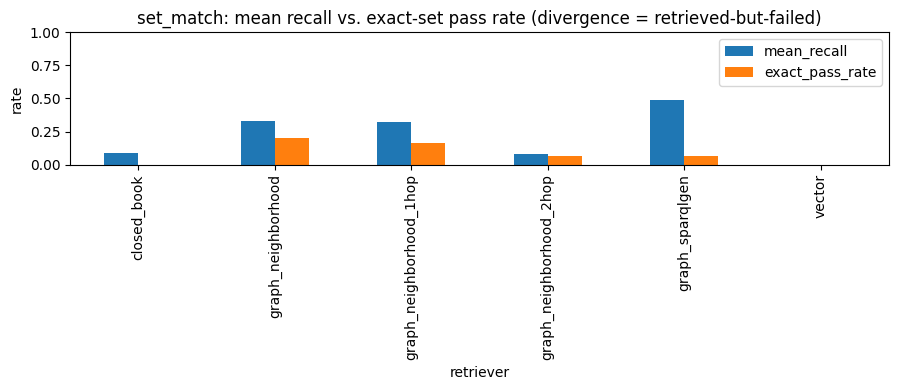

In [14]:
sm = canon[(canon["scoring"] == "set_match") & canon["recall"].notna()]
g = sm.groupby("retriever").agg(mean_recall=("recall", "mean"),
                                exact_pass_rate=("passed", "mean"),
                                n=("passed", "size"))
ax = g[["mean_recall", "exact_pass_rate"]].plot.bar(figsize=(9, 4))
ax.set_ylabel("rate"); ax.set_ylim(0, 1)
ax.set_title("set_match: mean recall vs. exact-set pass rate (divergence = retrieved-but-failed)")
plt.tight_layout()
g.round(2)

### Fig 3 — Precision leak on set questions

Where recall is high but extra rows sink F1 — `graph_sparqlgen`'s underconstrained queries return
supersets (worst on set-difference / 3+hop).

In [15]:
canon[canon["scoring"] == "set_match"].groupby("retriever").agg(
    recall=("recall", "mean"), precision=("precision", "mean"),
    f1=("f1", "mean"), mean_extra=("num_extra", "mean")).round(2)

,recall,precision,f1,mean_extra
retriever,,,,
closed_book,0.09,0.07,0.07,20.37
graph_neighborhood,0.33,0.38,0.39,2.20
graph_neighborhood_1hop,0.32,0.26,0.29,8.53
graph_neighborhood_2hop,0.08,0.15,0.14,7.50
graph_sparqlgen,0.49,0.54,0.56,2.87
vector,0.00,0.00,0.00,3.33


### Cost — retrieval context-input tokens (writer cost separate; summable only in $)

Two separate columns, deliberately **not added as tokens**:

- **`context_in`** = `retrieval_context_input_tokens` = the generator's billed `input_tokens` − the
  closed_book input for the *same question + model*. The input-side token weight the retrieved
  context contributes, isolated against the no-context baseline. The one unit-safe **token**
  decomposition — valid precisely because it never crosses a price boundary: same model, same
  direction (input), so the two counts share a rate. Output is excluded (different rate; and answer
  size barely moves across retrievers).
- **`writer_in`** = `writer_input_tokens` = the SPARQL-writer LLM cost *inside* `graph_sparqlgen`.
  `NaN` for the four no-writer retrievers — correct **by design**, not missing data.

Why not one "overall cost" **token** column? Not because tokens are abstract units — because the
pieces are priced at *different rates*. Each component can run a **different model** (here a
haiku/sonnet writer vs. the generator), and every model prices **input, cached-read, cache-creation,
and output** tokens differently. Adding raw counts across two models — or even input + output within
one — sums quantities at unequal prices: economically meaningless. It's the same class of error as the
[token-units rule](../retrievers/README.md#the-token-units-rule-read-before-doing-any-token-math)'s
proxy-vs-billed tokenizer mismatch, one level up (wrong *price* rather than wrong *tokenizer*).

The legitimate total is in **dollars, not tokens**. The fact table is already **wide** — each tier is
its own column per component (`input_tokens`, `output_tokens`, `cache_read_input_tokens`,
`cache_creation_input_tokens`; same for `writer_*` / `judge_*`) — so the price dim just needs matching
**per-tier rates** at grain `(date, model)`: multiply each token column by its rate, sum to a
per-component cost, then **sum the dollars** across components. You add dollars, never tokens. (Four
generator tiers, not three — cache *creation* and cache *read* price differently.) That pricing join
is a **downstream analytics step** (the spin-off repo); until then these stay as two separate,
same-unit token columns.

In [16]:
canon.groupby("retriever").agg(
    context_in=("retrieval_context_input_tokens", "mean"),
    writer_in=("writer_input_tokens", "mean")).round(1)

,context_in,writer_in
retriever,,
closed_book,0.0,NaN
graph_neighborhood,868.4,NaN
graph_neighborhood_1hop,714.9,NaN
graph_neighborhood_2hop,2319.4,NaN
graph_sparqlgen,238.9,574.6
vector,702.8,NaN


### Next

- **Canonical re-runs** on the new telemetry schema populate the writer / top_k / cache / cosine
  columns and the full-corpus `vector` arm — these cells then refresh automatically.
- The **polished notebook** imports the same `load()` and refines these into the definitive figures
  (and adds the type-08 sensitivity panel and the type-10 *uncalibrated* note).